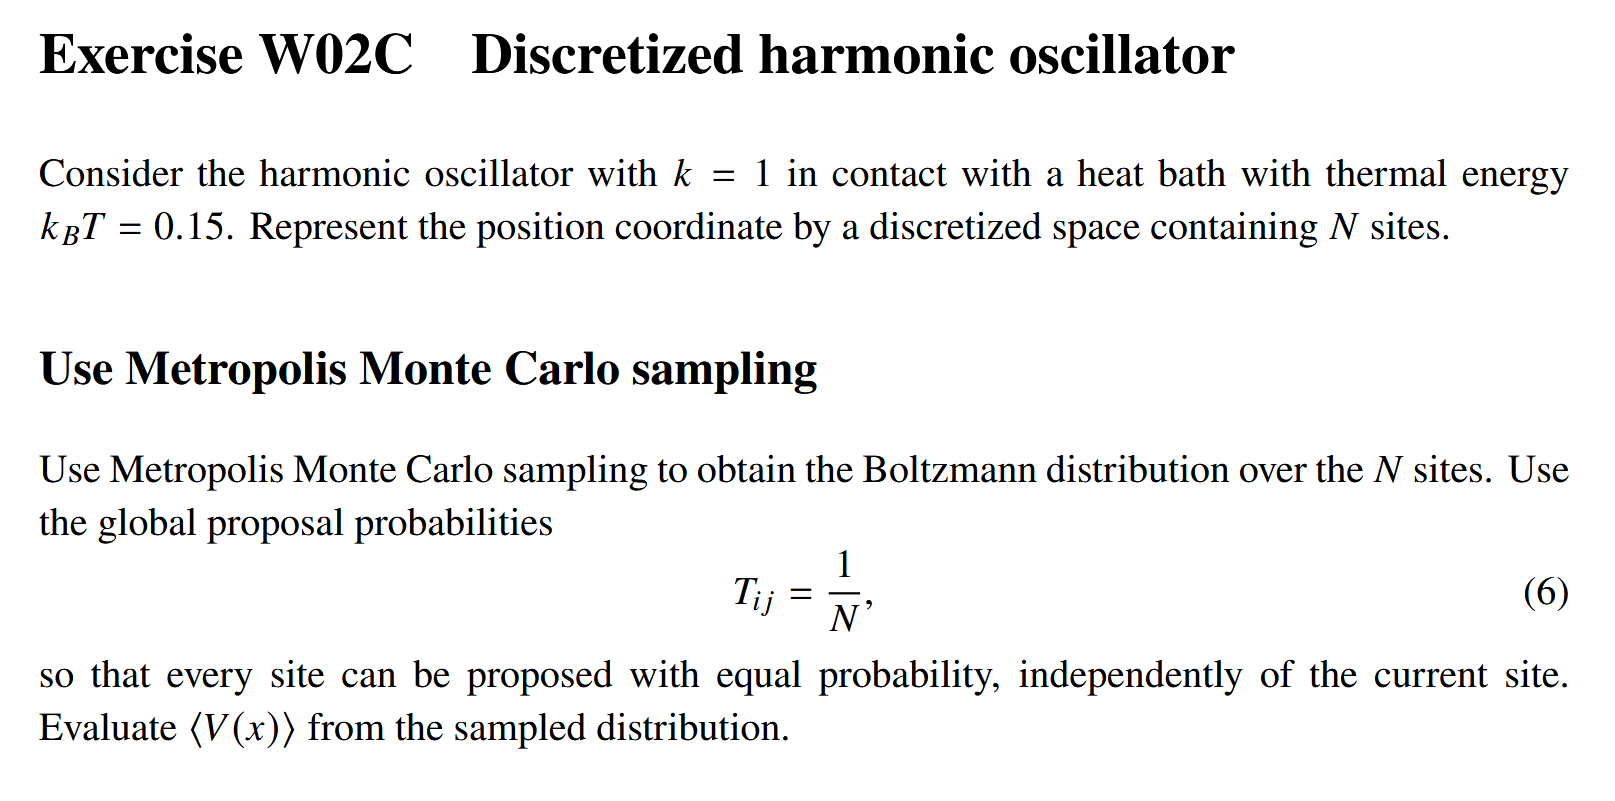

<V> = 0.075


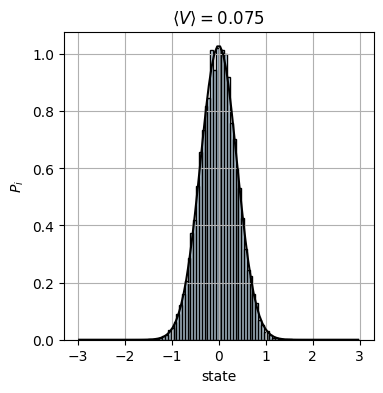

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Metropolis:
    def __init__(self, T, energies, initial, kbT=1/3):
        self.T = T
        self.energies = energies
        self.state = initial
        self.kbT = kbT
        self.counts = np.zeros(len(energies))

    def propse(self):
        """
        Looks at current state, and chooses a new index to jump to from T
        """
        i = self.state
        return np.random.choice(range(len(self.energies)), p=self.T[i])

    def step(self):
        """
        Looks at a proposed state and calculates the acceptance from 2.32
        Then chooses the next state. 
        """
        j = self.propse()
        A = min(1, self._exp(self.state, j))
        if np.random.rand() < A: 
            self.state = j

    def run_simulation(self, n=100_000):
        """
        Run simulation returns evaluate P ndarray
        """
        self.counts[self.state] += 1
        for _ in range(n):
            self.step()
            self.counts[self.state] += 1

        self.P = np.array(self.counts) / n
        return self.P

    def _exp(self, i, j):
        """
        Calculates the ratio P_j/P_i
        """
        return np.exp(-1/self.kbT * (self.energies[j]-self.energies[i]))


class HeatBath(Metropolis):
    def __init__(self, N, k=1, kbT=0.15, T=None):
        self.N = N
        self.k = k
        self.kbT = kbT

        self.x_edges = np.linspace(-3, 3, N+1)
        self.x = (self.x_edges[:-1] + self.x_edges[1:]) / 2

        if not np.any(T): 
            T = np.ones((N,N))*1/N
            
        energies = 1/2 * k * self.x**2
        super().__init__(T, energies, 0, self.kbT)

        self.p_exact = np.sqrt(self.k/(2* np.pi*self.kbT))*np.exp(-self.energies / self.kbT)


    def plot(self , ax):
        if not np.any(self.P): 
            raise Exception('Simulation not run')
        xwidth = self.x_edges[1] - self.x_edges[0]
        P = self.counts / np.sum(self.counts) / xwidth
        ax.bar(self.x, P, width=xwidth , facecolor='C0', alpha=0.25)
        ax.bar(self.x, P, width=xwidth , facecolor='None', edgecolor='k')
        ax.set_xlabel('state')
        ax.set_ylabel(r'$P_i$')
        ax.grid()
        ax.set_title(r'$\langle V\rangle=$'+f'{self.thermal_avg_V():.3f}')
        ax.plot(self.x, self.p_exact, 'k', label="Exact")

    def thermal_avg_V(self):
        if not np.any(self.P): 
            raise Exception('Simulation not run')

        return np.dot(self.P, np.array(self.energies))
        
sim = HeatBath(100)
sim.run_simulation()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sim.plot(ax)

print(f'<V> = {sim.thermal_avg_V():.3f}')


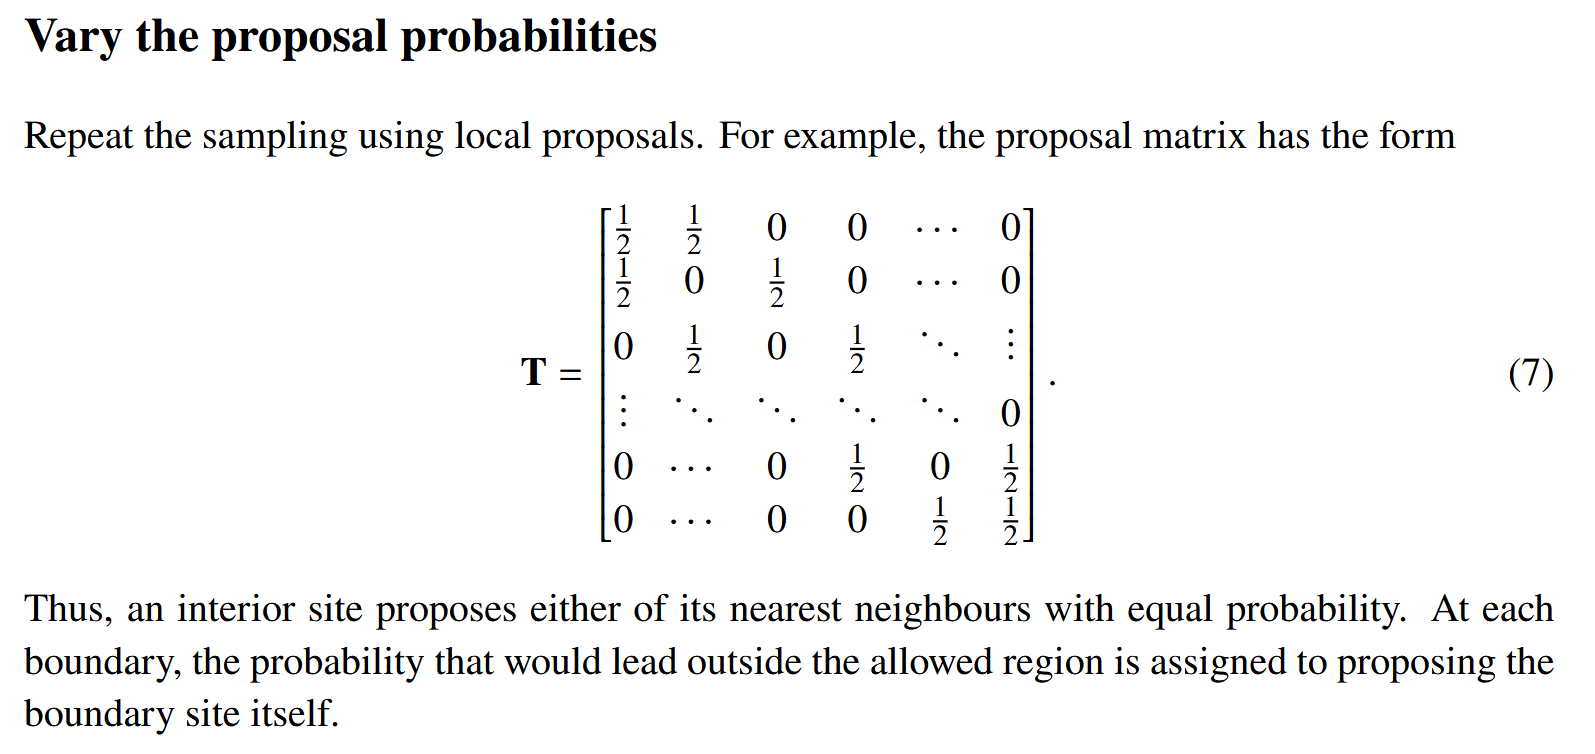

<V> = 0.076


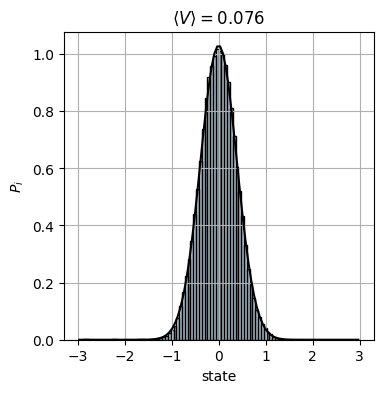

In [38]:
N = 100
T_local = np.zeros((N, N))
for i in range(1, N-1):
    T_local[i][i-1] = 1/2
    T_local[i][i+1] = 1/2
T_local[0][0:2] = 1/2
T_local[-1][-1:-3:-1] = 1/2

sim2 = HeatBath(N, T=T_local)
sim2.run_simulation()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sim2.plot(ax)

print(f'<V> = {sim2.thermal_avg_V():.3f}')